# Linear Regression: 
### Implement BGD, SGD, mini-batch; MSE loss; vectorized NumPy


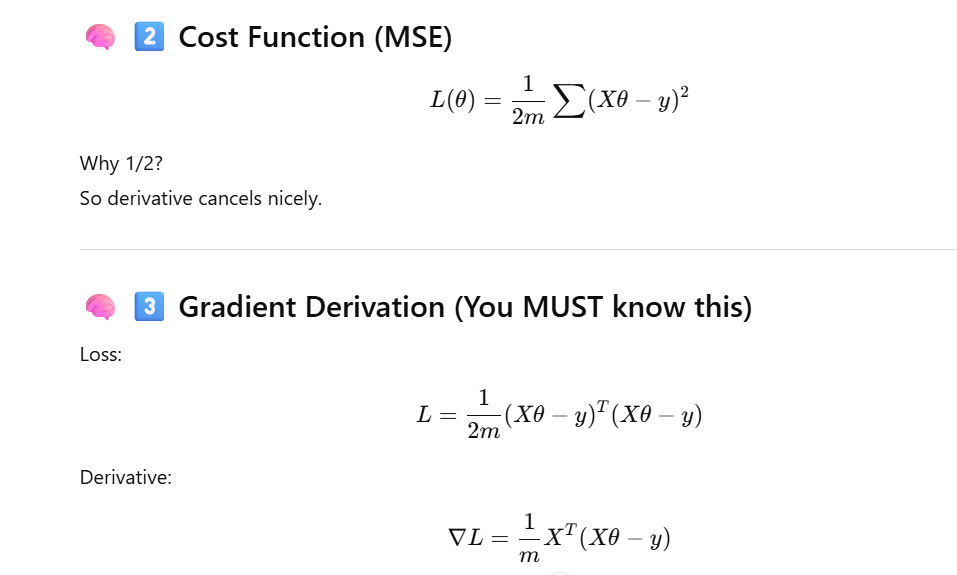

In [ ]:
import numpy as np

class LinearRegression:
    def __init__(self):
        self.theta = None
    
    def fit(self, X, y):
        # X: shape(m,n)
        # y: shape(m)

        m = X.shape[0]

        # Add bais column
        X = np.c_[np.ones(m), X]

        #Normal eq using pseudo-inverse
        self.theta = np.linalg.pinv(X) @ y

        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return X @ self.theta


In [6]:
def LinearRegression(X, y):
    m = X.shape[0]
    X = np.c_[np.ones(m), X]
    theta = np.linalg.pinv(X) @ y
    return theta

X = np.array([[1],[2],[3]])
y = np.array([3,5,7])

theta = LinearRegression(X, y)
print(theta)

[1. 2.]


# Linear Regression Gradient Descent

In [1]:
class LinearRegressionGD:
    def __init__(self, alpha=0.01, iterations=100):
        self.alpha = alpha
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape

        # Add bias column
        X = np.c_[np.ones(m), X]

        # Initialize weights
        self.theta = np.zeros(n+1)

        for _ in range(self.iterations):
            predictions = X @ self.theta
            error = predictions - y

            gradient = (1/m) * (X.T @ error)
            self.theta -= self.alpha * gradient

            # Compute cost
            cost = (1/(2*m)) * np.sum(error ** 2)
            self.cost_history.append(cost)

        return self
    
    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return X @ self.theta
    
    

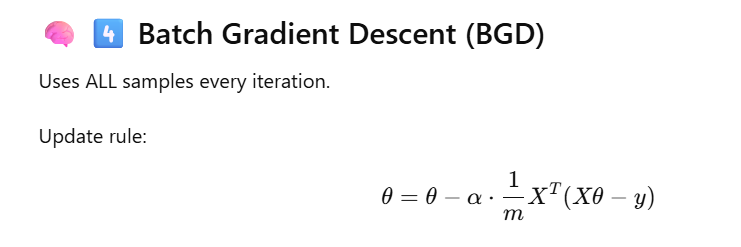

In [2]:
def LRGD(X, y, alpha=0.01, iteration=1000):
    m, n = X.shape
    X = np.c_[np.ones(m), X]
    theta = np.zeros(n+1)

    for _ in range(iteration):
        prediction = X @ theta
        error = prediction - y
        gradient = (1/m) * (X.T @ error)
        theta -= alpha * gradient

    return theta


In [3]:
# MSE Function
def mse(y_true, y_pred):
    m = len(y_true)
    return (1/2*m) * np.sum((y_pred - y_true) ** 2)

1️⃣ What if features are not scaled?

→ Convergence slow, zig-zag path.

2️⃣ Why vectorization instead of loops?

→ Uses optimized BLAS (C backend), 100x faster.

3️⃣ How detect divergence?

→ Cost increases each iteration.

4️⃣ When use Normal Equation?

→ Small dataset, low feature count.

5️⃣ What is time complexity?

Per iteration:

O(mn)

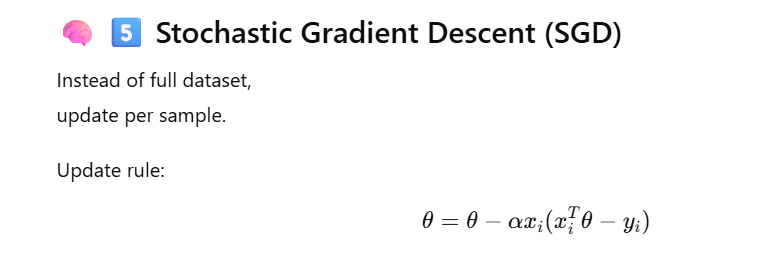

In [4]:
def lrsgd(X, y, alpha=0.01, iterations=100):
    m, n = X.shape
    theta = np.zeros(n)

    for _ in range(iterations):
        for i in range(m):
            xi = X[i]
            yi = y[i]
            error = xi @ theta - yi
            gradient = xi * error
            theta = theta - alpha * gradient

    return theta

In [5]:
# Mini Batch GD in Linear Regression

def lr_minibatch(X, y, alpha=0.01, iterations=100, batch_size=32):
    m, n = X.shape
    theta = np.zeros(n)

    for _ in range(iterations):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            error = X_batch @ theta - y_batch
            gradient = (1/len(X_batch)) * (X_batch.T @ error)
            theta = theta - alpha * gradient

    return theta



Q: Why divide by m?
A: To average gradient → stable learning rate.

Q: Why 1/2 in cost?
A: Cancels 2 in derivative.

Q: When use closed form vs GD?
A: Small data → closed form. Large data → GD.

Q: Why vectorization important?
A: Uses BLAS optimized C backend → much faster.